# Uniswap V2 — Simulateur d’arbitrage (CEX vs AMM), fees & analyses paramétriques



### Préambule — imports

Cette cellule charge les bibliothèques nécessaires :
- `numpy` pour les calculs vectorisés,
- `matplotlib` pour les graphiques,
- `ipywidgets` pour la partie interactive éventuelle.

Dans la suite, on travaille avec une pool **Uniswap V2** à produit constant,

$$x_t y_t = k_t,$$

avec un prix spot AMM exprimé en **token Y par token X**.



In [15]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Dict, Tuple

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _HAS_WIDGETS = True
except Exception:
    _HAS_WIDGETS = False


## 1) Fonctions communes (à réutiliser partout)

Tout ce qui suit sert de base à **toutes** les expériences. Nous allons tout d'abord décrire chacune des fonctions que nous avons implémentées dans une première partie puis mener des expériences à l'aide de ces fonctions

### Outils de temps et génération du prix CEX

Cette cellule met en place :
- les conversions de temps (jours/minutes vers années),
- une grille de temps régulière,
- un **Brownien standard** discretisé,
- un prix CEX modélisé par un **mouvement brownien géométrique** (GBM).

Le modèle utilisé est

$$
S_t = S_0 \exp\Big((\mu - \tfrac{1}{2}\sigma^2)t + \sigma W_t\Big),
$$

où :
- $\mu$ est le drift annualisé,
- $\sigma$ la volatilité annualisée,
- $W_t$ un Brownien standard.




In [16]:
DAYS_PER_YEAR = 365.0
HOURS_PER_YEAR = DAYS_PER_YEAR * 24.0
MINUTES_PER_YEAR = HOURS_PER_YEAR * 60.0

def years_from_days(days: float) -> float:
    return days / DAYS_PER_YEAR

def years_from_minutes(minutes: float) -> float:
    return minutes / MINUTES_PER_YEAR

# Prix CEX : GBM (Mouvement Brownien Géométrique)
def make_time_grid(T: float, dt: float) -> np.ndarray:
    N = int(np.round(T / dt)) + 1  # round pour éviter les erreurs de flottants
    return np.linspace(0.0, T, N)

def brownian_path(N: int, dt: float, seed: Optional[int] = None) -> np.ndarray:
    '''
    Génère un Brownien standard discrétisé cohérent avec W[0] = 0 :
      W[0] = 0,
      W[i] = \sum_{j=1}^{i} Z_j \sqrt{dt}, \quad Z_j \sim \mathcal{N}(0,1).
    '''
    if N < 1:
        raise ValueError("N doit être >= 1.")
    rng = np.random.default_rng(seed)
    dW = rng.standard_normal(N - 1) * np.sqrt(dt)
    W = np.empty(N)
    W[0] = 0.0
    if N > 1:
        W[1:] = np.cumsum(dW)
    return W

def gbm_from_brownian(t: np.ndarray, W: np.ndarray, mu: float, sigma: float, S0: float) -> np.ndarray:
    '''Trajectoire GBM à partir d'un Brownien W.'''
    return S0 * np.exp((mu - 0.5 * sigma**2) * t + sigma * W)

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_471/3188654121.py:20: SyntaxWarning: invalid escape sequence '\s'
  W[i] = \sum_{j=1}^{i} Z_j \sqrt{dt}, \quad Z_j \sim \mathcal{N}(0,1).


### Swaps exacts Uniswap V2 avec frais sur l’input

La cellule suivante code les deux swaps élémentaires de **Uniswap V2** avec frais proportionnels $\phi$ prélevés sur l’input.

Invariant de la pool :

$$x y = k.$$

Pour un swap **$Y \to X$** avec input brut $a$ :
- la quantité effectivement injectée dans l’invariant est $(1-\phi)a$,
- la réserve de Y devient $y' = y + a$,
- la sortie en X vaut

$$
\Delta x = \frac{x(1-\phi)a}{y + (1-\phi)a},
$$

- donc la nouvelle réserve de X vaut

$$
x' = x - \Delta x = \frac{xy}{y + (1-\phi)a}.
$$

Symétriquement, pour un swap **$X \to Y$** avec input brut $b$ :

$$
\Delta y = \frac{y(1-\phi)b}{x + (1-\phi)b},
\qquad
y' = y - \Delta y,
\qquad
x' = x + b.
$$

Le **prix spot** AMM utilisé ensuite est

$$
P = \frac{y}{x}.
$$


In [17]:

# Swap exact en prenant en compte les frais
def swap_y_for_x(x: float, y: float, amount_y_in: float, phi: float) -> Tuple[float, float, float, float]:
    '''
    Swap exact Uniswap V2 : on envoie Y dans la pool et on reçoit X.
    Frais prélevés sur l'input : fee = phi * amount_y_in.
    '''
    if amount_y_in <= 0:
        return x, y, 0.0, 0.0
    fee_y = phi * amount_y_in
    amount_in_eff = amount_y_in * (1.0 - phi)
    dx_out = x * amount_in_eff / (y + amount_in_eff)
    x_new = x - dx_out
    y_new = y + amount_y_in
    return x_new, y_new, dx_out, fee_y

def swap_x_for_y(x: float, y: float, amount_x_in: float, phi: float) -> Tuple[float, float, float, float]:
    '''
    Swap exact Uniswap V2 : on envoie X dans la pool et on reçoit Y.
    Frais prélevés sur l'input : fee = phi * amount_x_in.
    '''
    if amount_x_in <= 0:
        return x, y, 0.0, 0.0
    fee_x = phi * amount_x_in
    amount_in_eff = amount_x_in * (1.0 - phi)
    dy_out = y * amount_in_eff / (x + amount_in_eff)
    x_new = x + amount_x_in
    y_new = y - dy_out
    return x_new, y_new, dy_out, fee_x

def spot_price_y_per_x(x: float, y: float) -> float:
    '''Prix spot AMM : P = y/x (numéraire = Y).'''
    return y / x

### Taille de trade fermée pour atteindre un prix cible

Cette cellule résout analytiquement la taille du swap nécessaire pour amener le **prix spot** AMM vers un prix cible $P_{\text{target}}$.

Pour un swap **$Y \to X$** de taille brute $a$, on a

$$
P_{\text{after}}(a) = \frac{y'}{x'} = \frac{(y+a)(y+(1-\phi)a)}{xy}.
$$

En imposant $P_{\text{after}}(a)=P_{\text{target}}$, on obtient l’équation quadratique

$$
(1-\phi)a^2 + y(2-\phi)a + y^2 - P_{\text{target}}xy = 0.
$$

Pour un swap **$X \to Y$** de taille brute $b$, on a

$$
P_{\text{after}}(b) = \frac{y'}{x'} = \frac{xy}{(x+b)(x+(1-\phi)b)},
$$

et donc

$$
P_{\text{target}}(1-\phi)b^2 + P_{\text{target}}x(2-\phi)b + P_{\text{target}}x^2 - xy = 0.
$$

On garde ensuite la racine positive, qui correspond à une taille de trade économiquement admissible.


In [18]:

# Arbitrage : taille de trade fermée (1 trade) pour atteindre un prix spot cible
# -----------------------------
def _solve_trade_y_in_for_target_price(x: float, y: float, phi: float, P_target: float) -> float:
    '''
    Trouve amount_y_in >= 0 tel que le prix spot après swap (Y->X) devienne P_target.

    On résout :
      P_after(a) = (y+a)(y+(1-phi)a)/(x*y) = P_target
    => (1-phi)a^2 + y(2-phi)a + y^2 - P_target*x*y = 0
    '''
    A = (1.0 - phi)
    B = y * (2.0 - phi)
    C = y*y - P_target * x * y

    disc = B*B - 4.0*A*C
    if disc <= 0:
        return 0.0
    a = (-B + np.sqrt(disc)) / (2.0*A)
    return max(0.0, float(a))

def _solve_trade_x_in_for_target_price(x: float, y: float, phi: float, P_target: float) -> float:
    '''
    Trouve amount_x_in >= 0 tel que le prix spot après swap (X->Y) devienne P_target.

    On résout :
      P_after(a) = y*x / ((x+(1-phi)a)(x+a)) = P_target
    => P_target(1-phi)a^2 + P_target*x(2-phi)a + P_target*x^2 - x*y = 0
    '''
    A = P_target * (1.0 - phi)
    B = P_target * x * (2.0 - phi)
    C = P_target * x * x - x * y

    disc = B*B - 4.0*A*C
    if disc <= 0 or A <= 0:
        return 0.0
    a = (-B + np.sqrt(disc)) / (2.0*A)
    return max(0.0, float(a))



### Paramètres du modèle

Cette structure rassemble les paramètres de simulation :
- horizon $T$,
- pas $\Delta t$,
- paramètres du CEX $(\mu,\sigma,S_0)$,
- frais Uniswap V2 $\phi$,
- liquidité initiale,
- vitesse de réaction de l’arbitrage.

L’initialisation de la pool est choisie pour avoir

$$
x_0 = L_x,
\qquad
y_0 = L_x S_0,
\qquad
P_0 = \frac{y_0}{x_0} = S_0.
$$

Ainsi, le prix initial de l’AMM coïncide avec le prix initial du CEX.


In [19]:
@dataclass
class SimParams:
    # horizon & pas (en années)
    T: float = years_from_days(30.0)
    dt: float = years_from_minutes(10.0)

    # CEX (GBM)
    mu: float = 0.0
    sigma: float = 0.5
    S0: float = 10.0
    seed: Optional[int] = 42

    # Uniswap V2
    phi: float = 0.003
    initial_liquidity_x: float = 10_000.0  # réserve initiale de X
    # on initialise y0 = x0 * S0 pour que P0 = S0

    # Arbitrage "réaction"
    alpha: float = 1.0              # 1.0 = arbitrage instantané (1 trade), <1 = ajustement progressif
    latency_minutes: float = 0.0    # délai avant arbitrage quand sortie de bande
    retarget: bool = True           # si True, la cible suit le CEX pendant la réaction




### Boucle principale de simulation CEX vs AMM

La prochaine cellule sert à simuler la dynamique conjointe entre :
- un prix externe $S_t$ sur CEX,
- une pool **Uniswap V2** $(x_t,y_t)$,
- un arbitrage qui intervient quand le prix CEX sort de la zone de non-arbitrage.

Le prix spot AMM est

$$
P_t = \frac{y_t}{x_t}.
$$

Avec des frais $\phi$ sur l’input, les **bornes marginales** de non-arbitrage sont approchées par

$$
\text{upper} = \frac{P_t}{1-\phi},
\qquad
\text{lower} = P_t(1-\phi).
$$

Interprétation :
- si $S_t > \frac{P_t}{1-\phi}$, acheter X sur l’AMM en payant Y devient profitable,
- si $S_t < P_t(1-\phi)$, vendre X à l’AMM contre Y devient profitable.

Le paramètre `alpha` règle la fraction du trade optimal effectivement exécutée à chaque pas :

$$
\text{trade exécuté} = \alpha \times \text{trade optimal},
\qquad 0 < \alpha \le 1.
$$

La série `fees_value_Y` sert de **suivi de valorisation instantanée** des frais cumulés en numéraire Y ; pour les comparaisons finales, le notebook utilise ensuite une valorisation dédiée en fin d’horizon.


In [20]:
def simulate_uniswap_v2(params: SimParams, S_cex: Optional[np.ndarray] = None, W: Optional[np.ndarray] = None) -> Dict[str, np.ndarray]:
    '''
    Simule une pool Uniswap V2 arbitrée par rapport à un prix CEX.


    Modèle d'arbitrage (bande simple autour du prix AMM) :
      upper = P/(1-phi), lower = P*(1-phi)
    Si S_cex sort, l'arbitragiste ramène (plus ou moins vite) le spot AMM vers la frontière.
    '''
    t = make_time_grid(params.T, params.dt)
    N = len(t)

    # CEX path
    if S_cex is None:
        if W is None:
            W = brownian_path(N, params.dt, seed=params.seed)
        S_cex = gbm_from_brownian(t, W, params.mu, params.sigma, params.S0)
    else:
        S_cex = np.asarray(S_cex, dtype=float)
        if len(S_cex) != N:
            raise ValueError("S_cex doit avoir la même longueur que t (défini par T/dt).")

    # Pool state
    x = np.zeros(N)
    y = np.zeros(N)
    fee_x_cum = np.zeros(N)
    fee_y_cum = np.zeros(N)
    reacting = np.zeros(N, dtype=bool)

    x[0] = params.initial_liquidity_x
    y[0] = params.initial_liquidity_x * params.S0

    # Latency  (en steps)
    dt_minutes = params.dt * MINUTES_PER_YEAR
    latency_steps = int(round(params.latency_minutes / dt_minutes)) if params.latency_minutes > 0 else 0
    countdown = 0
    last_direction = 0  # +1 => Y->X (prix monte), -1 => X->Y (prix baisse), 0 => idle

    for i in range(1, N):
        x[i], y[i] = x[i-1], y[i-1]
        fee_x_cum[i], fee_y_cum[i] = fee_x_cum[i-1], fee_y_cum[i-1]

        P = spot_price_y_per_x(x[i], y[i])
        S = S_cex[i]

        upper = P / (1.0 - params.phi)
        lower = P * (1.0 - params.phi)

        # Détection : sortie de bande
        direction = 0
        if S > upper:
            direction = +1
        elif S < lower:
            direction = -1

        # Latence : si nouvelle sortie => on démarre un compte à rebours
        if direction != 0 and (last_direction == 0):
            countdown = latency_steps

        if direction == 0:
            countdown = 0
            last_direction = 0
            reacting[i] = False
            continue

        reacting[i] = True

        if countdown > 0:
            countdown -= 1
            last_direction = direction
            continue

        # Cible : frontière de non-arb (simple)
        # retarget : on réévalue direction/cible à chaque pas (si le CEX bouge)
        if params.retarget:
            P = spot_price_y_per_x(x[i], y[i])
            upper = P / (1.0 - params.phi)
            lower = P * (1.0 - params.phi)
            direction = +1 if S > upper else (-1 if S < lower else 0)
            if direction == 0:
                last_direction = 0
                reacting[i] = False
                continue

        if direction == +1:
            P_target = S * (1.0 - params.phi)
            amount_y_in_star = _solve_trade_y_in_for_target_price(x[i], y[i], params.phi, P_target)
            amount_y_in = params.alpha * amount_y_in_star
            x_new, y_new, _, fee_y = swap_y_for_x(x[i], y[i], amount_y_in, params.phi)
            x[i], y[i] = x_new, y_new
            fee_y_cum[i] += fee_y
        else:
            P_target = S / (1.0 - params.phi)
            amount_x_in_star = _solve_trade_x_in_for_target_price(x[i], y[i], params.phi, P_target)
            amount_x_in = params.alpha * amount_x_in_star
            x_new, y_new, _, fee_x = swap_x_for_y(x[i], y[i], amount_x_in, params.phi)
            x[i], y[i] = x_new, y_new
            fee_x_cum[i] += fee_x

        last_direction = direction

    P_amm = y / x
    fees_value_Y = fee_x_cum * S_cex + fee_y_cum  # valorisation instantanée en Y au prix CEX courant (série de suivi)

    return {
        "t": t,
        "S_cex": S_cex,
        "x": x,
        "y": y,
        "P_amm": P_amm,
        "fee_x_cum": fee_x_cum,
        "fee_y_cum": fee_y_cum,
        "fees_value_Y": fees_value_Y,
        "reacting": reacting,
        "params": params,
    }


# Métriques & plots (communs)

def lp_value_Y(x: np.ndarray, y: np.ndarray, S: np.ndarray, lp_share: float = 1.0) -> np.ndarray:
    return lp_share * (x * S + y)

def hodl_value_Y(x0: float, y0: float, S: np.ndarray) -> np.ndarray:
    return x0 * S + y0



### Fonctions de synthèse et de visualisation

Cette cellule définit :
- la valeur d’un LP exprimée en numéraire Y,
- la valeur d’un portefeuille HODL de référence,
- des fonctions de résumé et de tracé.

Les valorisations sont :

$$
V_{\text{LP}}(t) = \lambda\,(x_t S_t + y_t),
$$

$$
V_{\text{HODL}}(t) = x_0 S_t + y_0,
$$

avec $\lambda$ la part du LP dans la pool.

La fonction `total_fees_final_Y` valorise le stock final de frais en X au prix final, soit :

$$
\text{Fees}_T^{(Y)} = \text{feeY}_T + \text{feeX}_T \times P_T,
$$

avec $P_T = P^{\text{AMM}}_T$ ou $P_T = S_T$ selon la convention retenue.


In [21]:
def summarize_run(out: Dict[str, np.ndarray], lp_share: float = 1.0) -> Dict[str, float]:
    S = out["S_cex"]
    x, y = out["x"], out["y"]

    x0 = x[0] * lp_share
    y0 = y[0] * lp_share
    V0 = x0 * S[0] + y0

    V_lp = lp_value_Y(x, y, S, lp_share=lp_share)
    V_hodl = hodl_value_Y(x0, y0, S)

    return {
        "V0_Y": float(V0),
        "V_lp_end_Y": float(V_lp[-1]),
        "V_hodl_end_Y": float(V_hodl[-1]),
        "LP_minus_HODL_end_Y": float(V_lp[-1] - V_hodl[-1]),
        "fees_end_Y": float(out["fees_value_Y"][-1]),
        "price_tracking_rmse": float(np.sqrt(np.mean((out["P_amm"] - out["S_cex"])**2))),
    }

def plot_basic(out: Dict[str, np.ndarray], title: str = "Expérience", x_max_days: float | None = None) -> None:
    t_days = out["t"] * DAYS_PER_YEAR
    S = out["S_cex"]
    P = out["P_amm"]
    x, y = out["x"], out["y"]
    fees = out["fees_value_Y"]

    plt.figure(figsize=(10, 4))
    plt.plot(t_days, S, label="Prix CEX")
    plt.plot(t_days, P, label="Prix AMM")
    if x_max_days is not None:
        plt.xlim(0, x_max_days)
    plt.xlabel("Temps (jours)")
    plt.ylabel("Prix (Y par X)")
    plt.title(f"{title} — Prix")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t_days, x, label="Réserve X")
    plt.plot(t_days, y, label="Réserve Y")
    if x_max_days is not None:
        plt.xlim(0, x_max_days)
    plt.xlabel("Temps (jours)")
    plt.ylabel("Réserves")
    plt.title(f"{title} — Réserves")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(t_days, fees, label="Frais cumulés (valeur Y)")
    if x_max_days is not None:
        plt.xlim(0, x_max_days)
    plt.xlabel("Temps (jours)")
    plt.ylabel("Frais (Y)")
    plt.title(f"{title} — Frais cumulés")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
#
# Frais : agrégats (communs)

def total_fees_final_Y(out: Dict[str, np.ndarray], price_for_valuation: str = "amm") -> float:
    '''
    Retourne la valeur totale des frais (en Y) en valorisant le stock de frais en X
    au prix final.

    price_for_valuation:
      - "amm" : prix spot AMM final (P_amm[-1])
      - "cex" : prix CEX final (S_cex[-1])
    '''
    fee_x = float(out["fee_x_cum"][-1])
    fee_y = float(out["fee_y_cum"][-1])
    if price_for_valuation == "cex":
        P = float(out["S_cex"][-1])
    else:
        P = float(out["P_amm"][-1])
    return fee_y + fee_x * P

def simulate_on_price_path(
    S_path: np.ndarray,
    dt: float,
    *,
    phi: float,
    initial_liquidity_x: float,
    alpha: float = 1.0,
    latency_minutes: float = 0.0,
    retarget: bool = True,
) -> Dict[str, np.ndarray]:
    '''
    Wrapper "cohérent" : on garde simulate_uniswap_v2 comme coeur,
    mais on l'alimente avec un chemin de prix déjà construit.
    '''
    S_path = np.asarray(S_path, dtype=float)
    if S_path.ndim != 1 or len(S_path) < 2:
        raise ValueError("S_path doit être un vecteur 1D de longueur >= 2.")

    p = SimParams(
        T=(len(S_path)-1) * dt,
        dt=dt,
        mu=0.0, sigma=0.0,  # ignorés quand S_cex est fourni
        S0=float(S_path[0]),
        seed=None,
        phi=float(phi),
        initial_liquidity_x=float(initial_liquidity_x),
        alpha=float(alpha),
        latency_minutes=float(latency_minutes),
        retarget=bool(retarget),
    )
    return simulate_uniswap_v2(p, S_cex=S_path)

## 2) Expérience de base (même protocole)

On simule 30 jours, pas de 10 minutes, frais 0.3% (Uniswap V2 “classique”), arbitrage instantané (**alpha=1**).

### Expérience de base

On lance ici le scénario de référence :
- horizon de 30 jours,
- pas de 10 minutes,
- volatilité annualisée $\sigma = 0.5$,
- frais $\phi = 0.003$ soit **0,3%**,
- arbitrage instantané (`alpha=1`) sans latence.

La pool démarre à l’équilibre avec

$$P_0 = S_0.$$

Les graphiques permettent ensuite de comparer trajectoires de prix, réserves et frais cumulés.


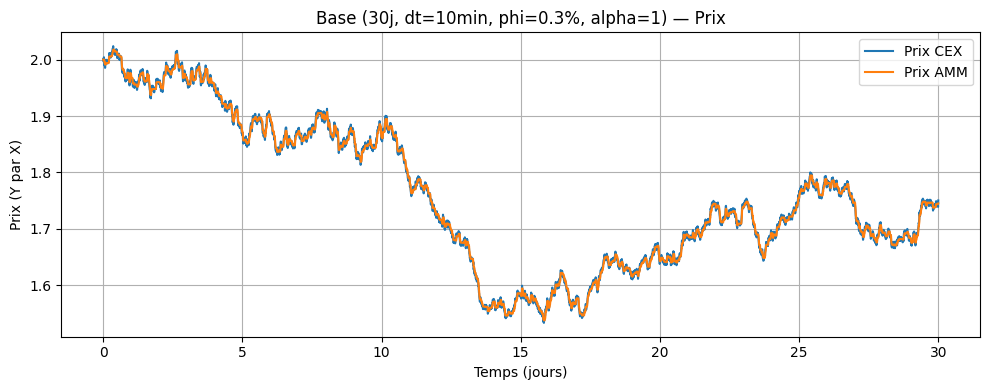

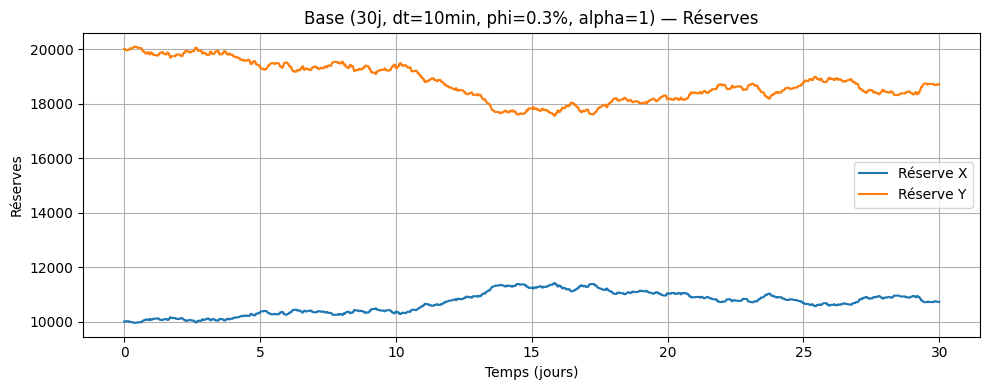

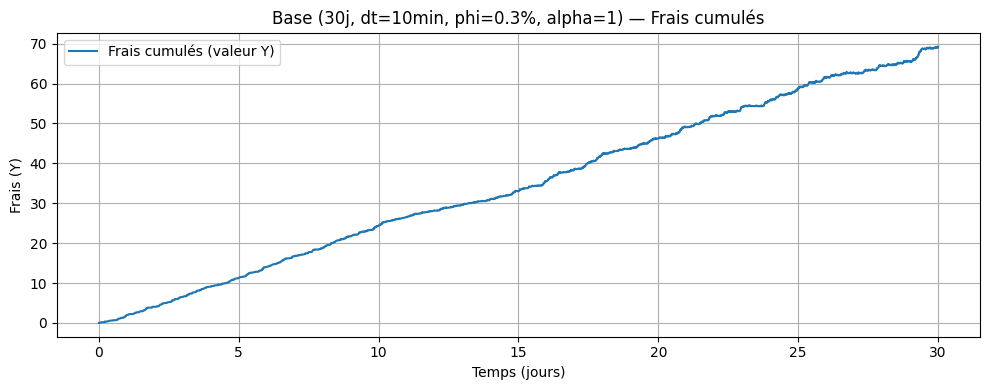

{'V0_Y': 40000.0,
 'V_lp_end_Y': 37490.24447675727,
 'V_hodl_end_Y': 37504.049438520364,
 'LP_minus_HODL_end_Y': -13.804961763096799,
 'fees_end_Y': 69.26650061204288,
 'price_tracking_rmse': 0.003991115115867176}

In [22]:
params = SimParams(
    T=years_from_days(30),
    dt=years_from_minutes(10),
    mu=0.0,
    sigma=0.5,
    S0=2,
    seed=42,
    phi=0.003,
    initial_liquidity_x=10_000.0,
    alpha=1.0,
    latency_minutes=0.0,
    retarget=True,
)

out = simulate_uniswap_v2(params)
plot_basic(out, title="Base (30j, dt=10min, phi=0.3%, alpha=1)")

summary = summarize_run(out)
summary

## 3) Zoom “bande de réaction” (latence + ajustement progressif)

Même modèle, mais :
- **latency_minutes** : délai avant que l’arbitrage démarre
- **alpha < 1** : on exécute seulement une fraction de la taille de trade optimale à chaque pas

Ça reproduit l’idée de “réaction” (sans dupliquer le code).

### Zoom sur la bande de réaction

On observe ici un cas avec :
- un pas plus fin (1 minute),
- une latence de 3 minutes,
- un arbitrage progressif avec $\alpha = 0.12$.

Les bornes affichées sont les bornes marginales de non-arbitrage :

$$
\left[P_t(1-\phi),\; \frac{P_t}{1-\phi}\right].
$$

Dès que le prix CEX sort de cette zone, l’arbitrage devient rentable, mais il ne corrige pas instantanément toute la déviation à cause de la latence et du facteur $\alpha$.




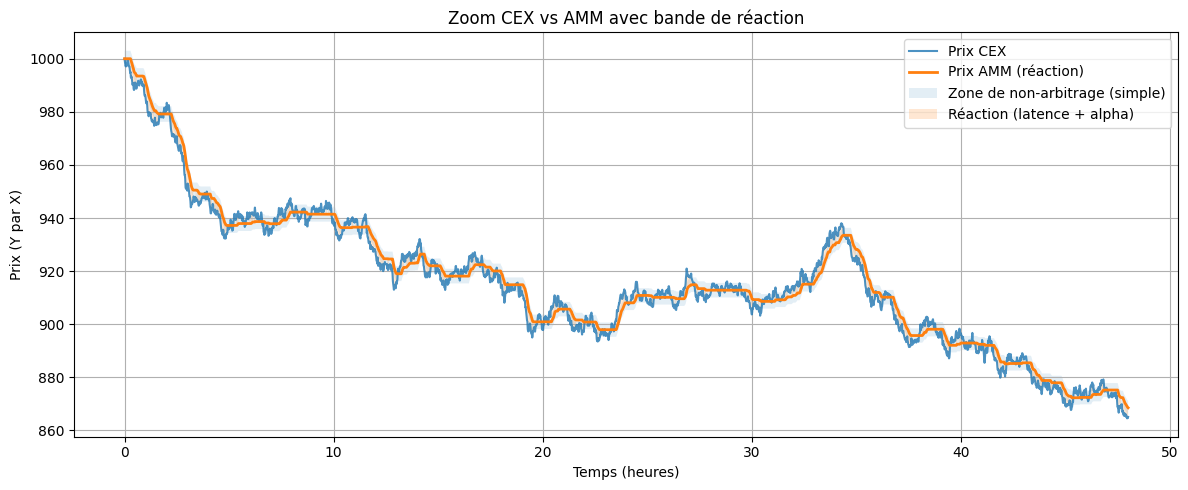

{'V0_Y': 20000000.0,
 'V_lp_end_Y': 18606149.750862144,
 'V_hodl_end_Y': 18650797.194922253,
 'LP_minus_HODL_end_Y': -44647.444060109556,
 'fees_end_Y': 4110.715813189975,
 'price_tracking_rmse': 3.475479310470498}

In [23]:
zoom_params = SimParams(
    T=years_from_days(2),
    dt=years_from_minutes(1),   # 1 minute
    mu=0.0,
    sigma=0.8,
    S0=1000.0,
    seed=10,
    phi=0.003,                   # 0.3% de frais (valeur Uniswap V2 classique)
    initial_liquidity_x=10_000.0,
    alpha=0.12,                 # ajustement progressif
    latency_minutes=3.0,        # latence
    retarget=True,
)

zoom = simulate_uniswap_v2(zoom_params)

# Plot : prix + zones (bande de non-arbitrage)
t_hours = zoom["t"] * HOURS_PER_YEAR
S = zoom["S_cex"]
P = zoom["P_amm"]
phi = zoom_params.phi

upper = P / (1 - phi)
lower = P * (1 - phi)
reacting = zoom["reacting"]

plt.figure(figsize=(12, 5))
plt.plot(t_hours, S, label="Prix CEX", alpha=0.8)
plt.plot(t_hours, P, label="Prix AMM (réaction)", linewidth=2)
plt.fill_between(t_hours, lower, upper, alpha=0.12, label="Zone de non-arbitrage (simple)")
plt.fill_between(t_hours, P, S, where=reacting, alpha=0.18, label="Réaction (latence + alpha)")
plt.title(r"Zoom CEX vs AMM avec bande de réaction")
plt.xlabel("Temps (heures)")
plt.ylabel("Prix (Y par X)")
plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

summarize_run(zoom)

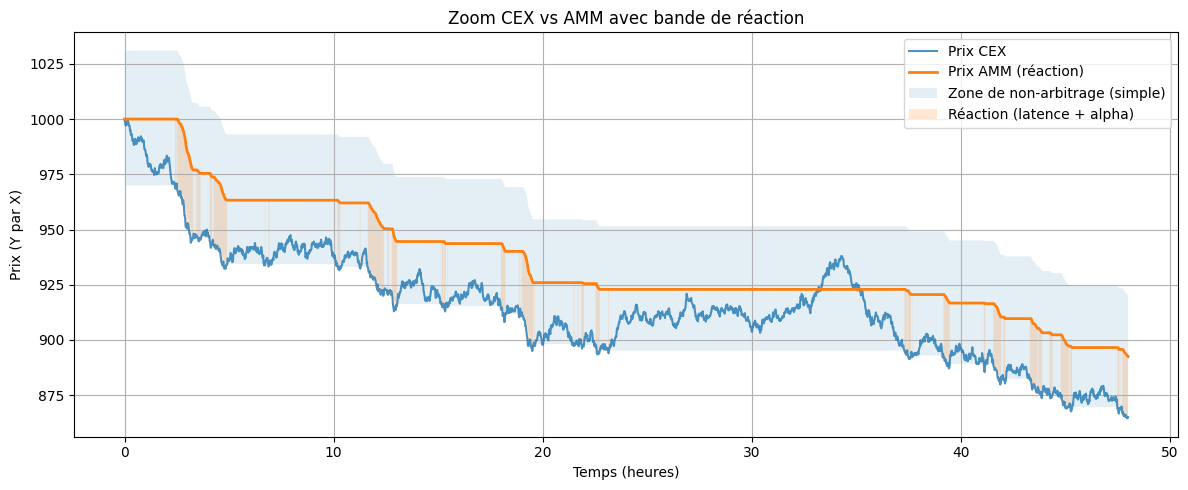

{'V0_Y': 20000000.0,
 'V_lp_end_Y': 18620312.34694072,
 'V_hodl_end_Y': 18650797.194922253,
 'LP_minus_HODL_end_Y': -30484.8479815349,
 'fees_end_Y': 15414.38760499103,
 'price_tracking_rmse': 21.972249880072813}

In [24]:
zoom_params = SimParams(
    T=years_from_days(2),
    dt=years_from_minutes(1),   # 1 minute
    mu=0.0,
    sigma=0.8,
    S0=1000.0,
    seed=10,
    phi=0.03,                   # 3% de frais on élarigt phi
    initial_liquidity_x=10_000.0,
    alpha=0.12,                 # ajustement progressif
    latency_minutes=3.0,        # latence
    retarget=True,
)

zoom = simulate_uniswap_v2(zoom_params)

# Plot : prix + zones (bande de non-arbitrage)
t_hours = zoom["t"] * HOURS_PER_YEAR
S = zoom["S_cex"]
P = zoom["P_amm"]
phi = zoom_params.phi

upper = P / (1 - phi)
lower = P * (1 - phi)
reacting = zoom["reacting"]

plt.figure(figsize=(12, 5))
plt.plot(t_hours, S, label="Prix CEX", alpha=0.8)
plt.plot(t_hours, P, label="Prix AMM (réaction)", linewidth=2)
plt.fill_between(t_hours, lower, upper, alpha=0.12, label="Zone de non-arbitrage (simple)")
plt.fill_between(t_hours, P, S, where=reacting, alpha=0.18, label="Réaction (latence + alpha)")
plt.title(r"Zoom CEX vs AMM avec bande de réaction")
plt.xlabel("Temps (heures)")
plt.ylabel("Prix (Y par X)")
plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

summarize_run(zoom)

### 4) Fees en fonction de $\Phi$, hypothèse $\gamma=\Phi$, et comparaison à la formule limite

On compare ici les fees simulés à la formule limite de l'article  
*Uniswap v3 - impermanent loss modeling
and swap fees asymptotic analysis*:

Dans le papier, les frais totaux en tokens $X$ et $Y$ sont écrits sous la forme

$$
\mathrm{Fees}_X^{0\to T}=\sum_R \Delta L_\pi\,\Delta\Phi_R^X,
\qquad
\mathrm{Fees}_Y^{0\to T}=\sum_R \Delta L_\pi\,\Delta\Phi_R^Y,
$$

où $\Delta\Phi_R^X$ et $\Delta\Phi_R^Y$ représentent les frais accumulés **par unité de liquidité** sur le range $R$.

Dans le cas GBM et pour un unique range fini $[p_\ell,p_u)$, le Théorème 4.3 donne alors

$$
\mathbb{E}^\*\!\left[\lim_{\phi\to 0}\left(\mathrm{Fees}_X^{0\to T}p_T+\mathrm{Fees}_Y^{0\to T}\right)\right]
=
\frac12\int_0^{\sigma^2T}\sqrt{p_0}\,e^{-v/8}
\left[
N\left(\frac{\ln(p_0/p_\ell)}{\sqrt v}\right)
-
N\left(\frac{\ln(p_0/p_u)}{\sqrt v}\right)
\right]dv,
$$

où $N$ désigne la fonction de répartition de la loi normale standard.

Pour passer au cas full-range / Uniswap v2, on fait tendre

$$
p_\ell\to 0,
\qquad
p_u\to +\infty.
$$

Dans ce cas,

$$
N\left(\frac{\ln(p_0/p_\ell)}{\sqrt v}\right)\to 1,
\qquad
N\left(\frac{\ln(p_0/p_u)}{\sqrt v}\right)\to 0,
$$

donc la formule devient

$$
\frac12\int_0^{\sigma^2T}\sqrt{p_0}\,e^{-v/8}\,dv
=
4\sqrt{p_0}\left(1-e^{-\sigma^2T/8}\right).
$$

Cette expression vaut pour **une unité de liquidité**. En multipliant par la liquidité $L$, on obtient

$$
4L\sqrt{p_0}\left(1-e^{-\sigma^2T/8}\right).
$$

Enfin, dans notre initialisation de type Uniswap v2, on a

$$
y_0=x_0p_0,
\qquad
L=\sqrt{x_0y_0}=x_0\sqrt{p_0},
$$

d'où

$$
4L\sqrt{p_0}\left(1-e^{-\sigma^2T/8}\right)
=
4x_0p_0\left(1-e^{-\sigma^2T/8}\right).
$$

C'est cette formule limite que l'on utilise comme benchmark théorique.

### Cellule de calcul Monte Carlo et comparaison à la formule du Théorème 4.3 du papier Uniswap V3


/tmp/ipykernel_471/877384663.py:34: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(0.5 * liquidity_L * np.trapz(integrand, v))


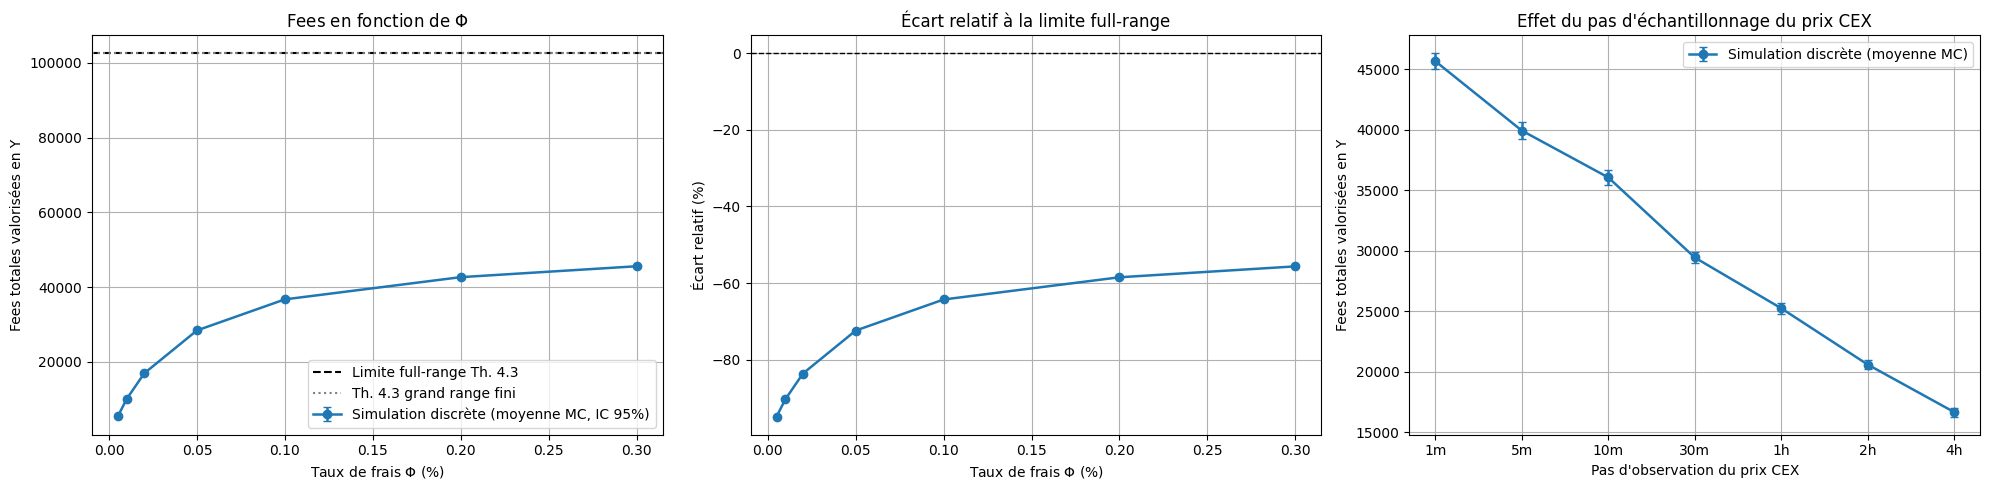

In [25]:
from math import erf


def norm_cdf(x: np.ndarray | float) -> np.ndarray | float:
    x_arr = np.asarray(x, dtype=float)
    out = 0.5 * (1.0 + np.vectorize(erf)(x_arr / np.sqrt(2.0)))
    if np.isscalar(x):
        return float(out)
    return out


def theorem_43_expected_total_fees_Y(
    *,
    p0: float,
    sigma: float,
    T: float,
    p_l: float,
    p_u: float,
    liquidity_L: float,
    n_quad: int = 4000,
) -> float:
    if not (p0 > 0 and sigma >= 0 and T >= 0 and p_l > 0 and p_u > p_l and liquidity_L >= 0):
        raise ValueError("Paramètres invalides.")

    total_var = sigma**2 * T
    if total_var == 0.0 or liquidity_L == 0.0:
        return 0.0

    v = np.linspace(1e-12, total_var, n_quad)
    z_l = np.log(p0 / p_l) / np.sqrt(v)
    z_u = np.log(p0 / p_u) / np.sqrt(v)

    integrand = np.sqrt(p0) * np.exp(-v / 8.0) * (norm_cdf(z_l) - norm_cdf(z_u))
    return float(0.5 * liquidity_L * np.trapz(integrand, v))


def theorem_43_full_range_limit_expected_total_fees_Y(
    *,
    p0: float,
    sigma: float,
    T: float,
    liquidity_L: float,
) -> float:
    if not (p0 > 0 and sigma >= 0 and T >= 0 and liquidity_L >= 0):
        raise ValueError("Paramètres invalides.")

    if sigma == 0.0 or T == 0.0 or liquidity_L == 0.0:
        return 0.0

    return float(4.0 * liquidity_L * np.sqrt(p0) * (1.0 - np.exp(-(sigma**2) * T / 8.0)))


def mc_average_fees_for_phi_grid(
    *,
    phis: np.ndarray,
    n_paths: int,
    T: float,
    dt: float,
    mu: float,
    sigma: float,
    S0: float,
    initial_liquidity_x: float,
    seed: int = 1234,
    independent_across_phi: bool = True,
) -> tuple[np.ndarray, np.ndarray]:
    phis = np.asarray(phis, dtype=float)
    t = make_time_grid(T, dt)
    n_steps = len(t)

    rng = np.random.default_rng(seed)
    fee_matrix = np.zeros((n_paths, len(phis)))

    for k in range(n_paths):
        if independent_across_phi:
            for j, phi in enumerate(phis):
                dW = rng.normal(0.0, np.sqrt(dt), size=n_steps - 1)
                W = np.concatenate(([0.0], np.cumsum(dW)))
                S_path = gbm_from_brownian(t, W, mu=mu, sigma=sigma, S0=S0)

                out = simulate_on_price_path(
                    S_path,
                    dt,
                    phi=float(phi),
                    initial_liquidity_x=initial_liquidity_x,
                    alpha=1.0,
                    latency_minutes=0.0,
                    retarget=True,
                )
                fee_matrix[k, j] = total_fees_final_Y(out, price_for_valuation="cex")
        else:
            dW = rng.normal(0.0, np.sqrt(dt), size=n_steps - 1)
            W = np.concatenate(([0.0], np.cumsum(dW)))
            S_path = gbm_from_brownian(t, W, mu=mu, sigma=sigma, S0=S0)

            for j, phi in enumerate(phis):
                out = simulate_on_price_path(
                    S_path,
                    dt,
                    phi=float(phi),
                    initial_liquidity_x=initial_liquidity_x,
                    alpha=1.0,
                    latency_minutes=0.0,
                    retarget=True,
                )
                fee_matrix[k, j] = total_fees_final_Y(out, price_for_valuation="cex")

    return fee_matrix.mean(axis=0), fee_matrix.std(axis=0, ddof=1)


def mc_average_fees_for_dt_grid(
    *,
    dt_minutes_list: list[int],
    phi: float,
    n_paths: int,
    T: float,
    mu: float,
    sigma: float,
    S0: float,
    initial_liquidity_x: float,
    seed: int = 9000,
) -> tuple[np.ndarray, np.ndarray]:
    means = []
    stds = []

    rng = np.random.default_rng(seed)

    for m in dt_minutes_list:
        dt = years_from_minutes(float(m))
        t = make_time_grid(T, dt)
        n_steps = len(t)
        vals = np.zeros(n_paths)

        for k in range(n_paths):
            dW = rng.normal(0.0, np.sqrt(dt), size=n_steps - 1)
            W = np.concatenate(([0.0], np.cumsum(dW)))
            S_path = gbm_from_brownian(t, W, mu=mu, sigma=sigma, S0=S0)

            out = simulate_on_price_path(
                S_path,
                dt,
                phi=float(phi),
                initial_liquidity_x=initial_liquidity_x,
                alpha=1.0,
                latency_minutes=0.0,
                retarget=True,
            )
            vals[k] = total_fees_final_Y(out, price_for_valuation="cex")

        means.append(vals.mean())
        stds.append(vals.std(ddof=1))

    return np.asarray(means), np.asarray(stds)


# ------------------------------------------------------------
# Paramètres
# ------------------------------------------------------------
T_cmp = years_from_days(30)
mu_cmp = 0.0
sigma_cmp = 0.5
S0_cmp = 1000.0
initial_liquidity_x_cmp = 10_000.0
L_cmp = initial_liquidity_x_cmp * np.sqrt(S0_cmp)

range_multiple = 100.0
p_l_cmp = S0_cmp / range_multiple
p_u_cmp = S0_cmp * range_multiple

theoretical_benchmark_finite_range_Y = theorem_43_expected_total_fees_Y(
    p0=S0_cmp,
    sigma=sigma_cmp,
    T=T_cmp,
    p_l=p_l_cmp,
    p_u=p_u_cmp,
    liquidity_L=L_cmp,
)

theoretical_benchmark_full_range_limit_Y = theorem_43_full_range_limit_expected_total_fees_Y(
    p0=S0_cmp,
    sigma=sigma_cmp,
    T=T_cmp,
    liquidity_L=L_cmp,
)

# ------------------------------------------------------------
# Monte Carlo
# ------------------------------------------------------------
phis = np.array([0.00005, 0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003])
n_paths_phi = 200

phi_means, phi_stds = mc_average_fees_for_phi_grid(
    phis=phis,
    n_paths=n_paths_phi,
    T=T_cmp,
    dt=years_from_minutes(1),
    mu=mu_cmp,
    sigma=sigma_cmp,
    S0=S0_cmp,
    initial_liquidity_x=initial_liquidity_x_cmp,
    seed=1234,
    independent_across_phi=True,
)

fixed_phi = 0.003
sampling_minutes = [1, 5, 10, 30, 60, 120, 240]
n_paths_dt = 100

dt_means, dt_stds = mc_average_fees_for_dt_grid(
    dt_minutes_list=sampling_minutes,
    phi=fixed_phi,
    n_paths=n_paths_dt,
    T=T_cmp,
    mu=mu_cmp,
    sigma=sigma_cmp,
    S0=S0_cmp,
    initial_liquidity_x=initial_liquidity_x_cmp,
    seed=9000,
)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].errorbar(
    phis * 100,
    phi_means,
    yerr=1.96 * phi_stds / np.sqrt(n_paths_phi),
    marker="o",
    linewidth=1.8,
    capsize=3,
    label="Simulation discrète (moyenne MC, IC 95%)",
)
axes[0].axhline(
    theoretical_benchmark_full_range_limit_Y,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Limite full-range Th. 4.3",
)
axes[0].axhline(
    theoretical_benchmark_finite_range_Y,
    color="gray",
    linestyle=":",
    linewidth=1.5,
    label="Th. 4.3 grand range fini",
)
axes[0].set_title("Fees en fonction de $\\Phi$")
axes[0].set_xlabel("Taux de frais $\\Phi$ (%)")
axes[0].set_ylabel("Fees totales valorisées en Y")
axes[0].grid(True)
axes[0].legend()

relative_gap_phi = (phi_means - theoretical_benchmark_full_range_limit_Y) / theoretical_benchmark_full_range_limit_Y
axes[1].plot(phis * 100, 100 * relative_gap_phi, marker="o", linewidth=1.8)
axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[1].set_title("Écart relatif à la limite full-range")
axes[1].set_xlabel("Taux de frais $\\Phi$ (%)")
axes[1].set_ylabel("Écart relatif (%)")
axes[1].grid(True)

axes[2].errorbar(
    [f"{m}m" if m < 60 else (f"{m//60}h" if m % 60 == 0 else f"{m}m") for m in sampling_minutes],
    dt_means,
    yerr=1.96 * dt_stds / np.sqrt(n_paths_dt),
    marker="o",
    linewidth=1.8,
    capsize=3,
    label="Simulation discrète (moyenne MC)",
)
axes[2].set_title("Effet du pas d'échantillonnage du prix CEX")
axes[2].set_xlabel("Pas d'observation du prix CEX")
axes[2].set_ylabel("Fees totales valorisées en Y")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

De manière logique, on observe que la quantité de fees collectés diminue avec l'augmentation du pas de sampling du prix CEX. En réalité, il ne faudrait pas utiliser un sampling path constant, mais directement utiliser une suite $(t_i)_{i \geq 0}$ telle que $$t_{i+1} := inf \{t \in \mathbb{R_+} | t \geq t_{i}, p_t = p_{t_i}(1 - \phi) \text{ ou } p_t = \frac{p_{t_i}}{(1 - \phi)} \}  $$

Lorsque l'on utilise un pas de sampling constant, on sous-estime grandement le nombres de fois ou le prix CEX varie suffisamment pour qu'un trade soit déclenché.
Heureusement, nous avons une formule explicite qui nous permet de sampler une telle suite $(t_i)_{i \geq 0}$.

En effet, en reprenant les notations de l'article susmentionné, sous une probabilité risque-neutre, on peut modéliser le prix dans l'amm $p_t$ comme une martingale, ce qui implique que $\mathbb{E}[p_{t_1} | \mathcal{F}_0] = p_0$. Un swap se produit lorsque le prix atteint soit la borne inférieure $p_0(1-\phi)$, soit la borne supérieure $p_0(1-\phi)^{-1}$

Soit $P_{up}$ la probabilité d'atteindre la borne supérieure en premier, et $P_{down} = 1 - P_{up}$ la probabilité d'atteindre la borne inférieure. L'équation de l'espérance s'écrit :
\begin{equation}
    P_{up} \cdot \frac{p_0}{1-\phi} + (1 - P_{up}) \cdot p_0(1-\phi) = p_0
\end{equation}

En simplifiant, on obtient :
$$P_{up} = \frac{1-\phi}{2-\phi}$$

La probabilité d'atteindre la borne inférieure est donc $P_{down} = 1 - P_{up} = \frac{1}{2-\phi}$. On remarque que $P_{up} < 0.5$ (la probabilité de monter est légèrement inférieure à celle de descendre pour compenser le fait que le saut à la hausse est proportionnellement plus grand).

Pour évaluer le temps moyen $\mathbb{E}[\tau]$ on considère le logarithme du prix :

- pour un mouvement vers le haut, on a $ln(p_t) - ln(p_t(1-\phi)^{-1}) = ln(1-\phi)$

- pour un mouvement vers le haut, on a $ln(p_t) - ln(p_t(1-\phi)) = -ln(1-\phi)$

On observe que les bornes multiplicatives deviennent des bornes additives rigoureusement symétriques $\pm h$ avec :
\begin{equation}
    h = -\ln(1-\phi)
\end{equation}

Par la formule d'Ito, puisque le prix est une martingale prix martingale ($dp_t = \sigma p_t dW_t$), on obtient :
\begin{equation}
    d(\ln p_t) = -\frac{\sigma^2}{2} dt + \sigma dW_t \implies \nu = -\frac{\sigma^2}{2}
\end{equation}


On utilise ensuite le résultat classique pour le temps de sortie d'un ABM d'un intervalle symétrique $[-h, h]$ est :
\begin{equation}
    \mathbb{E}[\tau] = \frac{h}{\nu} \tanh\left(\frac{\nu \cdot h}{\sigma^2}\right)
\end{equation}

En substituant $\nu = -\frac{\sigma^2}{2}$ et en exploitant l'imparité de la fonction tangente hyperbolique, les signes négatifs s'annulent :
\begin{align*}
    \mathbb{E}[\tau] &= \frac{h}{-\sigma^2/2} \tanh\left(\frac{(-\sigma^2/2) \cdot h}{\sigma^2}\right) \\
    \mathbb{E}[\tau] &= -\frac{2h}{\sigma^2} \tanh\left(-\frac{h}{2}\right) \\
    \mathbb{E}[\tau] &= \frac{2h}{\sigma^2} \tanh\left(\frac{h}{2}\right)
\end{align*}

In [26]:
def event_driven_mc_average_fees(
    *,
    phis: np.ndarray,
    n_paths: int,
    T: float,
    sigma: float,
    S0: float,
    liquidity_L: float,
    seed: int = 1234,
) -> tuple[np.ndarray, np.ndarray]:
    means = []
    stds = []
    rng = np.random.default_rng(seed)
    for phi in phis:
        p_up = (1.0 - phi) / (2.0 - phi) # Probabilité d'un saut vers le haut
        h = - np.log(1.0 - phi)
        E_tau = (2.0 * h / (sigma**2)) * np.tanh(0.5 * h) # Nombre de sauts moyen
        n_steps = int(T / E_tau)
        fees_Y_path = np.zeros(n_paths)
        for k in range(n_paths):
            steps = np.where(rng.random(n_steps) < p_up, 1, -1)
            log_price_changes = np.where(steps == 1, h, -h)
            log_prices = np.log(S0) + np.cumsum(log_price_changes)
            prices = np.exp(log_prices)
            prices_before = np.concatenate(([S0], prices[:-1]))
            pi_before = np.sqrt(prices_before)
            fee_factor = ((np.sqrt(1.0 + phi) - 1.0) * phi) / (1.0 - phi)
            fees_Y = np.where(steps == 1, pi_before * fee_factor * liquidity_L, 0.0) # Si le prix augmente on a swappé du Y
            fees_X = np.where(steps == -1, (1.0 / pi_before) * fee_factor * liquidity_L, 0.0) # Si le prix diminue on a swappé du X
            P_final = prices[-1]
            total_value_Y = np.sum(fees_Y) + np.sum(fees_X) * P_final
            fees_Y_path[k] = total_value_Y
        means.append(fees_Y_path.mean())
        stds.append(fees_Y_path.std(ddof=1))
    return np.array(means), np.array(stds)

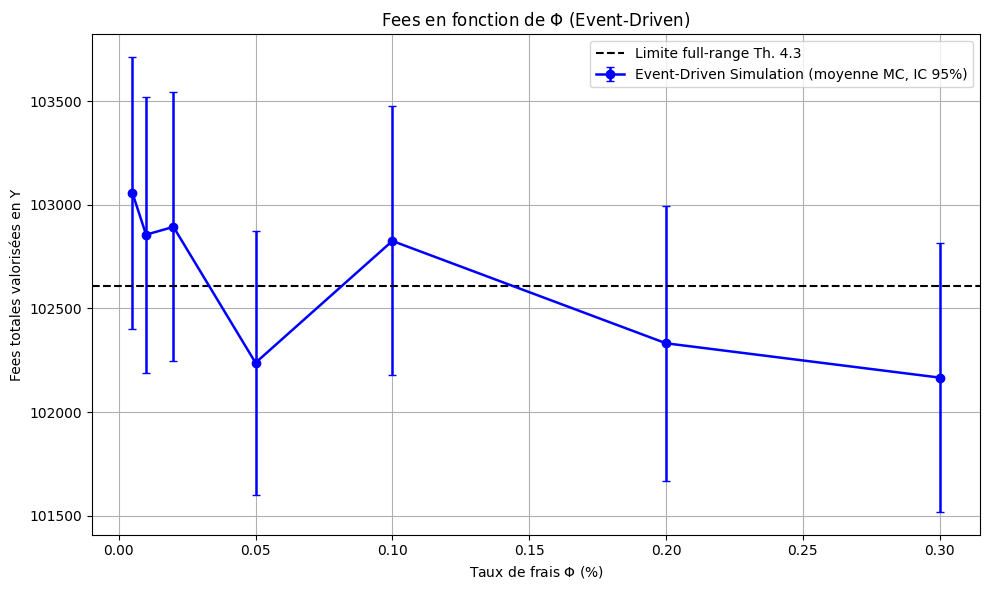

In [27]:
phis = np.array([0.00005, 0.0001, 0.0002, 0.0005, 0.001, 0.002, 0.003])
n_paths_phi = 500

phi_means_event, phi_stds_event = event_driven_mc_average_fees(
    phis=phis,
    n_paths=n_paths_phi,
    T=T_cmp,
    sigma=sigma_cmp,
    S0=S0_cmp,
    liquidity_L=L_cmp,
    seed=1234
)
plt.figure(figsize=(10, 6))
plt.errorbar(
    phis * 100,
    phi_means_event,
    yerr=1.96 * phi_stds_event / np.sqrt(n_paths_phi),
    marker="o",
    linewidth=1.8,
    capsize=3,
    color="blue",
    label="Event-Driven Simulation (moyenne MC, IC 95%)",
)
plt.axhline(
    theoretical_benchmark_full_range_limit_Y,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label="Limite full-range Th. 4.3",
)

plt.title("Fees en fonction de $\\Phi$ (Event-Driven)")
plt.xlabel("Taux de frais $\\Phi$ (%)")
plt.ylabel("Fees totales valorisées en Y")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

On observe maintenant que la quantité de fees obtenus est très proche de la limite théorique, là où avant on était très en dessous de cette limite.

## 5) LP vs HODL (même run, métriques cohérentes)

- **HODL** : tu gardes (x0, y0) constants  
- **LP** : tu détiens une part *lp_share* de la pool (x(t), y(t))

### Comparaison LP vs HODL

On compare ici deux stratégies à partir du même état initial :
- **HODL** : conserver $(x_0,y_0)$,
- **LP** : détenir une part fixe de la pool rééquilibrée par arbitrage.

Les valorisations en numéraire Y sont

$$
V_{\text{HODL}}(t) = x_0 S_t + y_0,
$$

$$
V_{\text{LP}}(t) = \lambda(x_t S_t + y_t).
$$

La quantité tracée

$$
V_{\text{LP}}(t) - V_{\text{HODL}}(t)
$$
avec $\lambda$ est simplement la part de la pool détenue par le LP

Cela mesure directement la surperformance ou sous-performance du LP par rapport à un portefeuille passif de référence.


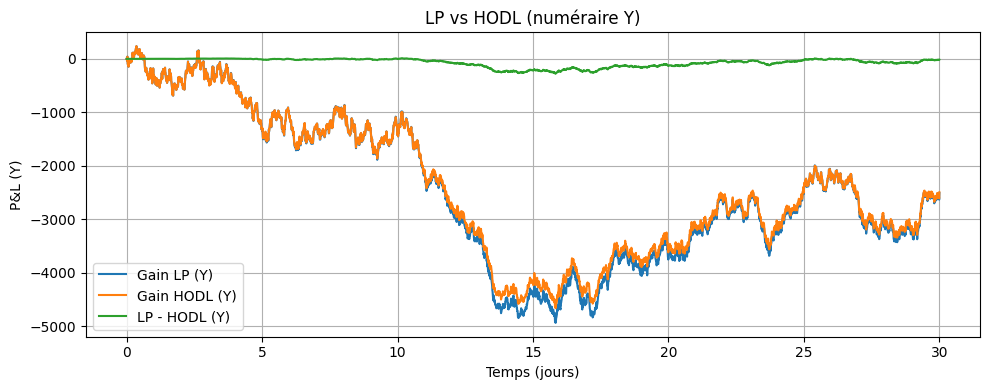

{'V0_Y': 40000.0,
 'V_lp_end_Y': 37490.24447675727,
 'V_hodl_end_Y': 37504.049438520364,
 'LP_minus_HODL_end_Y': -13.804961763096799,
 'fees_end_Y': 69.26650061204288,
 'price_tracking_rmse': 0.003991115115867176}

In [28]:
lp_share = 1.0  # 1.0 = 100% de la pool

S = out["S_cex"]
x, y = out["x"], out["y"]

x0 = x[0] * lp_share
y0 = y[0] * lp_share
V0 = x0 * S[0] + y0

V_hodl = hodl_value_Y(x0, y0, S)
V_lp = lp_value_Y(x, y, S, lp_share=lp_share)

plt.figure(figsize=(10, 4))
plt.plot(out["t"] * DAYS_PER_YEAR, V_lp - V0, label="Gain LP (Y)")
plt.plot(out["t"] * DAYS_PER_YEAR, V_hodl - V0, label="Gain HODL (Y)")
plt.plot(out["t"] * DAYS_PER_YEAR, V_lp - V_hodl, label="LP - HODL (Y)")
plt.xlabel("Temps (jours)")
plt.ylabel("P&L (Y)")
plt.title("LP vs HODL (numéraire Y)")
plt.grid(True); plt.legend()
plt.tight_layout()
plt.show()

summarize_run(out, lp_share=lp_share)

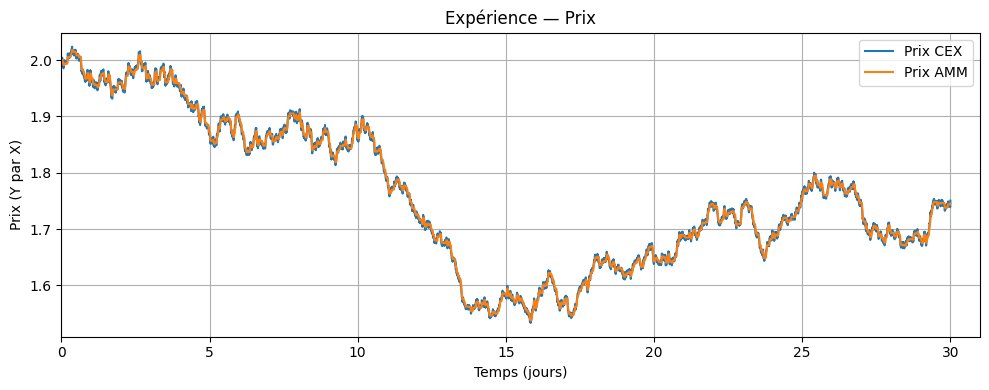

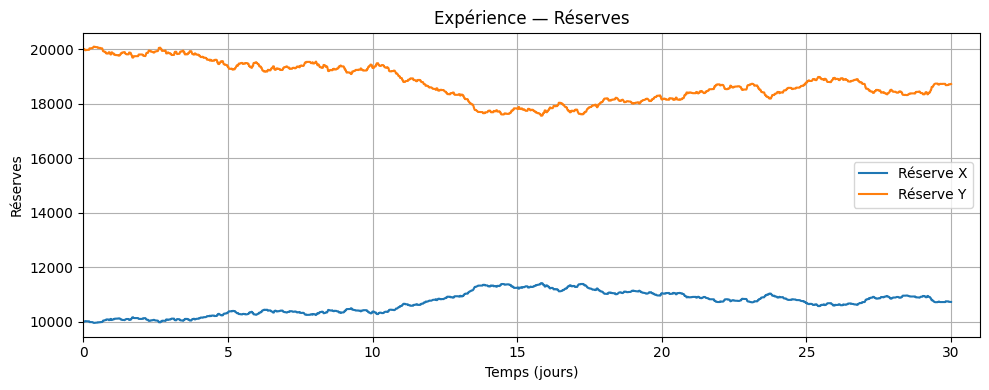

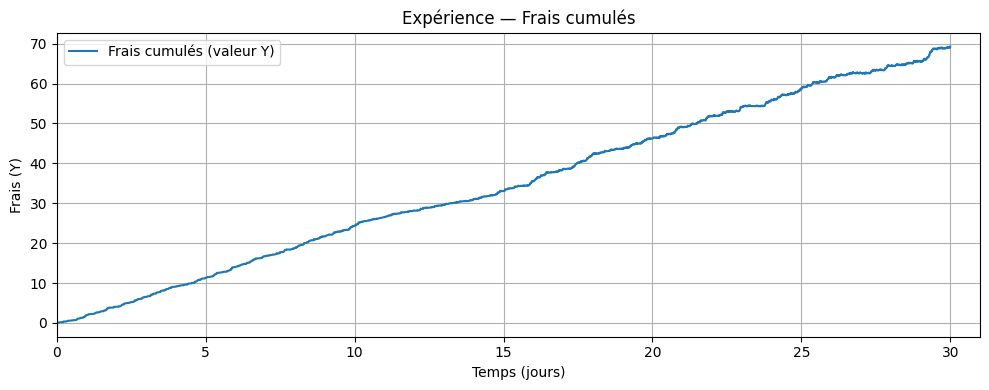

In [29]:
summarize_run(out, lp_share=lp_share)
plot_basic(out, title="Expérience", x_max_days=31)

## 6) Interactivité (pool + swaps)

Deux widgets :
1. **Explorateur de paramètres** (T, dt, σ, μ, φ, liquidité, alpha, latence) → plots automatiques  
2. **Pool interactive** à un instant *t* : visualisation de la courbe *x·y=k* et effet d’un swap (X→Y ou Y→X)

> Vaut mieux exécuter dans colab pour voir les widgets

### Partie interactive — explorateur de paramètres

Cette section crée des widgets pour explorer visuellement les paramètres du modèle. Comme demandé, cette partie n’est pas revue en détail ici ; le cœur mathématique pertinent pour **Uniswap V2** se trouve dans les cellules précédentes.


In [30]:

# Explorateur de paramètres (réserves X/Y + fees cumulés

w_days  = widgets.IntSlider(value=30, min=1, max=180, step=1, description="T (jours)")
w_dt    = widgets.IntSlider(value=10, min=1, max=60, step=1, description="dt (min)")
w_phi   = widgets.FloatSlider(value=0.003, min=0.0, max=0.05, step=0.001, description="phi")
w_Lx    = widgets.FloatSlider(value=10_000, min=1_000, max=100_000, step=1_000, description="Lx")
w_alpha = widgets.FloatSlider(value=1.0, min=0.05, max=1.0, step=0.05, description="alpha")
w_lat   = widgets.FloatSlider(value=0.0, min=0.0, max=30.0, step=1.0, description="lat (min)")
w_seed  = widgets.IntText(value=42, description="seed")

out_box = widgets.Output()

def _run_and_plot(change=None):
    with out_box:
        clear_output(wait=True)

        p = SimParams(
            T=years_from_days(w_days.value),
            dt=years_from_minutes(w_dt.value),

            # Valeurs fixes
            mu=0.0,
            sigma=0.5,
            S0=1000.0,
            seed=int(w_seed.value),

            phi=float(w_phi.value),
            initial_liquidity_x=float(w_Lx.value),

            alpha=float(w_alpha.value),
            latency_minutes=float(w_lat.value),
            retarget=True,
        )

        out_loc = simulate_uniswap_v2(p)

        t_days = out_loc["t"] * DAYS_PER_YEAR
        S = out_loc["S_cex"]
        P = out_loc["P_amm"]
        x = out_loc["x"]
        y = out_loc["y"]


        # Prix : S_CEX & P_AMM

        plt.figure(figsize=(10, 4.5))
        plt.plot(t_days, S, linewidth=2, label="S_CEX (prix externe)")
        plt.plot(t_days, P, linewidth=2, label="P_AMM (y/x)")
        plt.title("Explorateur : Prix CEX vs Prix AMM")
        plt.xlabel("Temps (jours)")
        plt.ylabel("Prix (en Y par X)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


        # 2) Réserves X & Y (mêmes axes, couleurs différentes)

        plt.figure(figsize=(10, 4.2))
        l1, = plt.plot(t_days, x, linewidth=2, label="Réserve X")
        l2, = plt.plot(t_days, y, linewidth=2, label="Réserve Y")
        plt.title("Évolution des réserves de la pool (X et Y)")
        plt.xlabel("Temps (jours)")
        plt.ylabel("Réserves (unités)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Fees cumulés (en Y)

        fee_x_cum = None
        fee_y_cum = None

        if "fee_x_cum" in out_loc and "fee_y_cum" in out_loc:
            fee_x_cum = np.asarray(out_loc["fee_x_cum"], dtype=float)
            fee_y_cum = np.asarray(out_loc["fee_y_cum"], dtype=float)
        elif "fee_x" in out_loc and "fee_y" in out_loc:
            fee_x_cum = np.cumsum(np.asarray(out_loc["fee_x"], dtype=float))
            fee_y_cum = np.cumsum(np.asarray(out_loc["fee_y"], dtype=float))
        else:
            print("Note: out_loc ne contient pas fee_x_cum/fee_y_cum ni fee_x/fee_y -> fees cumulés non traçables.")

        if fee_x_cum is not None and fee_y_cum is not None:
            fees_cum_Y = fee_y_cum + fee_x_cum * np.asarray(P, dtype=float)

            plt.figure(figsize=(10, 4.0))
            plt.plot(t_days, fees_cum_Y, linewidth=2)
            plt.title("Fees cumulés (valorisés en Y au prix AMM courant)")
            plt.xlabel("Temps (jours)")
            plt.ylabel("Fees cumulés (Y)")
            plt.grid(True)
            plt.tight_layout()
            plt.show()

        print(summarize_run(out_loc))

for w in [w_days, w_dt, w_phi, w_Lx, w_alpha, w_lat, w_seed]:
    w.observe(_run_and_plot, names="value")

controls = widgets.VBox([
    widgets.HBox([w_days, w_dt, w_seed]),
    widgets.HBox([w_phi, w_Lx, w_alpha]),
    widgets.HBox([w_lat]),
])

display(widgets.HTML("<b>Explorateur de paramètres</b>"))
display(controls, out_box)
_run_and_plot()

HTML(value='<b>Explorateur de paramètres</b>')

Output()

### Partie interactive — sandbox de pool

Cette seconde partie interactive sert à manipuler visuellement une pool $(x,y)$, son prix spot et l’impact d’un swap. Elle n’est pas nécessaire pour comprendre ou valider les formules du modèle principal.


In [31]:

# Sandbox Pool (x,y) : liquidité, prix, slippage & impact

display(widgets.HTML("<hr><b>Sandbox Pool (x,y) : liquidité, prix, slippage & impact</b>"))

w2_lock_price = widgets.Checkbox(value=True, description="Verrouiller le prix (y = x·P)")

w2_x = widgets.FloatLogSlider(value=10_000.0, base=10, min=2, max=7, step=0.05,
                              description="x", readout_format=".2f")
w2_P = widgets.FloatLogSlider(value=1000.0, base=10, min=0, max=6, step=0.05,
                              description="P (y/x)", readout_format=".2f")
w2_y = widgets.FloatLogSlider(value=10_000_000.0, base=10, min=2, max=10, step=0.05,
                              description="y", readout_format=".2f")


w2_phi = widgets.FloatSlider(value=0.003, min=0.0, max=0.05, step=0.001, description="phi")

w2_dir = widgets.Dropdown(
    options=[("Y → X (buy X)", "y_for_x"), ("X → Y (sell X)", "x_for_y")],
    value="y_for_x",
    description="Swap"
)
w2_amt = widgets.FloatLogSlider(value=1_000.0, base=10, min=0, max=7, step=0.05,
                                description="amount_in", readout_format=".2f")
w2_sweep = widgets.FloatLogSlider(value=100_000.0, base=10, min=0, max=8, step=0.05,
                                  description="sweep max", readout_format=".2f")

sandbox_box = widgets.Output()

def _plot_sandbox(change=None):
    with sandbox_box:
        clear_output(wait=True)

        phi = float(w2_phi.value)

        x = float(w2_x.value)
        if w2_lock_price.value:
            P = float(w2_P.value)
            y = x * P
        else:
            y = float(w2_y.value)
            P = y / max(1e-18, x)

        k = x * y
        V_Y = x * P + y  # valeur approx en Y au prix spot

        # Swap preview
        amount_in = float(w2_amt.value)
        if w2_dir.value == "y_for_x":
            x2, y2, dx_out, fee_y = swap_y_for_x(x, y, amount_in, phi)
            P2 = y2 / x2
            eff_price = amount_in / max(1e-18, dx_out)  # Y par X
            slip_pct = (eff_price / P - 1.0) * 100.0
            desc = f"Tu envoies {amount_in:,.2f} Y → tu reçois {dx_out:,.6f} X (fee {fee_y:,.2f} Y)"
        else:
            x2, y2, dy_out, fee_x = swap_x_for_y(x, y, amount_in, phi)
            P2 = y2 / x2
            eff_price = dy_out / max(1e-18, amount_in)  # Y par X
            slip_pct = (eff_price / P - 1.0) * 100.0
            desc = f"Tu envoies {amount_in:,.6f} X → tu reçois {dy_out:,.2f} Y (fee {fee_x:,.6f} X)"

        impact_pct = (P2 / P - 1.0) * 100.0

        print(f"Réserves : x={x:,.2f}   y={y:,.2f}   k=x·y={k:,.2e}")
        print(f"Prix spot : P=y/x={P:,.6f}   Valeur pool ~ {V_Y:,.2f} Y")
        print(f"Frais φ : {phi*100:.3f}%")
        print(desc)
        print(f"Après swap : x'={x2:,.2f}   y'={y2:,.2f}   P'={P2:,.6f}")
        print(f"  • Price impact (P' vs P) : {impact_pct:+.3f}%")
        print(f"  • Prix effectif          : {eff_price:,.6f} Y/X   (slippage {slip_pct:+.3f}%)")

        # Courbe x·y=k
        xs = np.linspace(max(1e-12, 0.3*x), 1.7*x, 250)
        ys = k / xs

        plt.figure(figsize=(7, 5))
        plt.plot(xs, ys, linewidth=2, label="Courbe x·y=k")
        plt.scatter([x], [y], s=60, label="Avant")
        plt.scatter([x2], [y2], s=60, label="Après swap")
        plt.xlabel("Réserve X")
        plt.ylabel("Réserve Y")
        plt.title("Constante x·y=k (impact du swap)")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Impact vs taille de trade
        sweep_max = float(w2_sweep.value)
        amts = np.linspace(0.0, sweep_max, 80)

        impacts = []
        for a in amts:
            if w2_dir.value == "y_for_x":
                xa, ya, _, _ = swap_y_for_x(x, y, float(a), phi)
            else:
                xa, ya, _, _ = swap_x_for_y(x, y, float(a), phi)
            Pa = ya / xa
            impacts.append((Pa / P - 1.0) * 100.0)

        plt.figure(figsize=(8, 4))
        plt.plot(amts, impacts, linewidth=2)
        plt.xlabel("Taille du swap (token d'entrée)")
        plt.ylabel("Impact prix (%)")
        plt.title("Impact prix vs taille de trade (plus de liquidité ⇒ courbe plus plate)")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

for w in [w2_lock_price, w2_x, w2_P, w2_y, w2_phi, w2_dir, w2_amt, w2_sweep]:
    w.observe(_plot_sandbox, names="value")

sandbox_controls = widgets.VBox([
    widgets.HBox([w2_lock_price, w2_phi]),
    widgets.HBox([w2_x, w2_P, w2_y]),
    widgets.HBox([w2_dir, w2_amt, w2_sweep]),
])

display(sandbox_controls, sandbox_box)
_plot_sandbox()

HTML(value='<hr><b>Sandbox Pool (x,y) : liquidité, prix, slippage & impact</b>')

Output()